**Link Dataset** : https://www.kaggle.com/datasets/aslanahmedov/market-basket-analysis

## Import Library

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from datetime import datetime, timedelta
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import itertools
import networkx as nx
import pickle
import joblib
import warnings
warnings.filterwarnings("ignore")

## Data Preparation

### Data Loading

In [2]:
# Load data
df = pd.read_excel('dataset/Assignment-1_Data.xlsx')
df.head()

,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Exploratory Data Analysis (EDA)

In [3]:
# Cek informasi umum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   BillNo      522064 non-null  object        
 1   Itemname    520609 non-null  object        
 2   Quantity    522064 non-null  int64         
 3   Date        522064 non-null  datetime64[ns]
 4   Price       522064 non-null  float64       
 5   CustomerID  388023 non-null  float64       
 6   Country     522064 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 27.9+ MB


In [4]:
# Statistik deskriptif
df.describe()

,Quantity,Date,Price,CustomerID
count,522064.000000,522064,522064.000000,388023.000000
mean,10.090435,2011-07-04 12:51:20.777107456,3.826801,15316.931710
min,-9600.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 10:15:00,1.250000,13950.000000
50%,3.000000,2011-07-20 08:59:00,2.080000,15265.000000
75%,10.000000,2011-10-19 14:12:00,4.130000,16837.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,161.110525,NaN,41.900599,1721.846964


In [5]:
# Cek missing values
df.isnull().sum()

BillNo             0
Itemname        1455
Quantity           0
Date               0
Price              0
CustomerID    134041
Country            0
dtype: int64

In [6]:
# Cek jumlah data duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

Jumlah baris duplikat: 5286


In [7]:
# Identifikasi Kolom Numerik dan Kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nKolom Numerik: {num_cols}")
print(f"Kolom Kategorikal: {cat_cols}")


Kolom Numerik: ['Quantity', 'Price', 'CustomerID']
Kolom Kategorikal: ['BillNo', 'Itemname', 'Country']


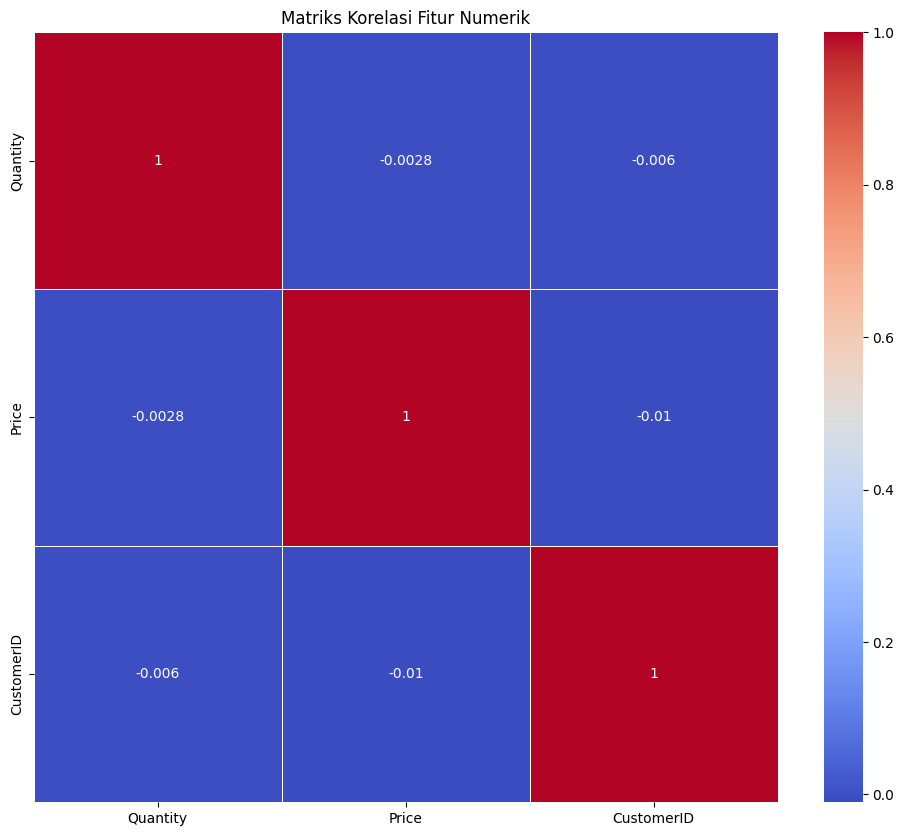

In [8]:
# Analisis Korelasi untuk Fitur Numerik
if len(num_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[num_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Matriks Korelasi Fitur Numerik')
    plt.show()

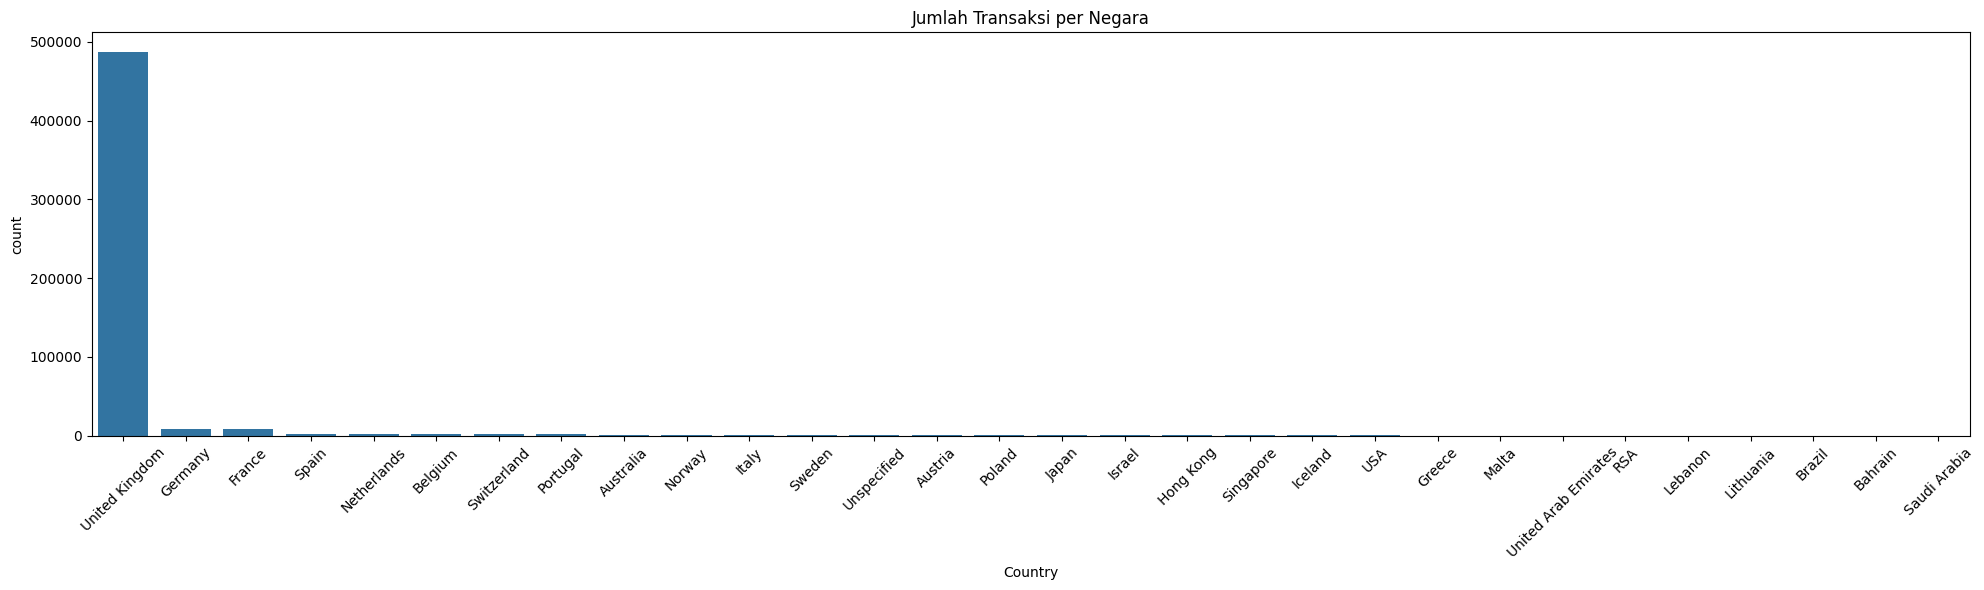

In [9]:
# Distribusi Transaksi per Negara
plt.figure(figsize=(20, 6))
sns.countplot(data=df, x='Country', order=df['Country'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Jumlah Transaksi per Negara')
plt.tight_layout()
plt.show()

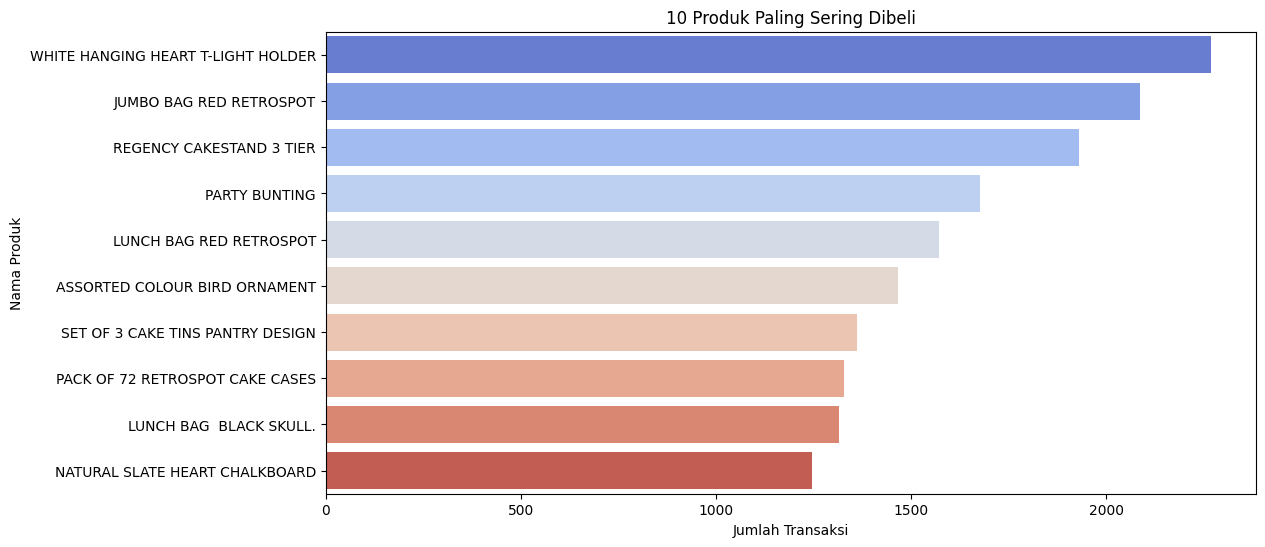

In [10]:
# 10 Produk Terpopuler
top_items = df['Itemname'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.values, y=top_items.index, palette='coolwarm')
plt.title('10 Produk Paling Sering Dibeli')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Nama Produk')
plt.show()

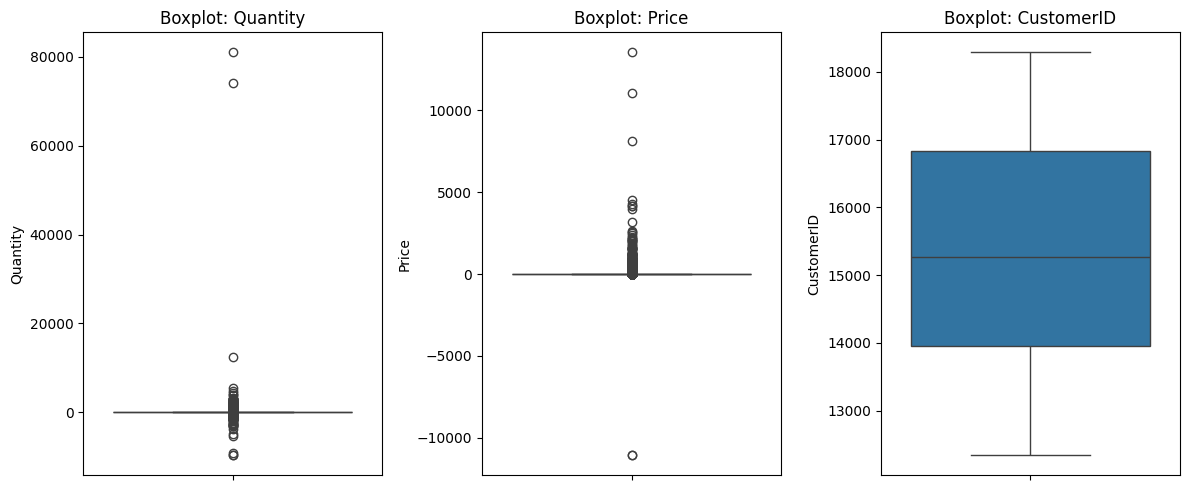

In [11]:
# Deteksi Outlier
plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

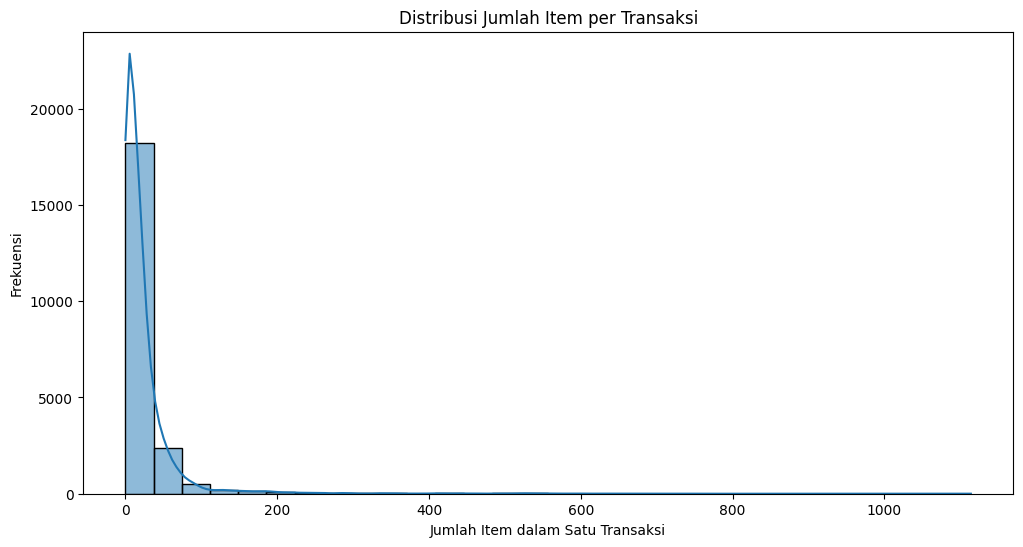

In [12]:
# Distribusi Jumlah Item dalam Transaksi
items_per_invoice = df.groupby('BillNo')['Itemname'].count()

plt.figure(figsize=(12, 6))
sns.histplot(items_per_invoice, bins=30, kde=True)
plt.title('Distribusi Jumlah Item per Transaksi')
plt.xlabel('Jumlah Item dalam Satu Transaksi')
plt.ylabel('Frekuensi')
plt.show()

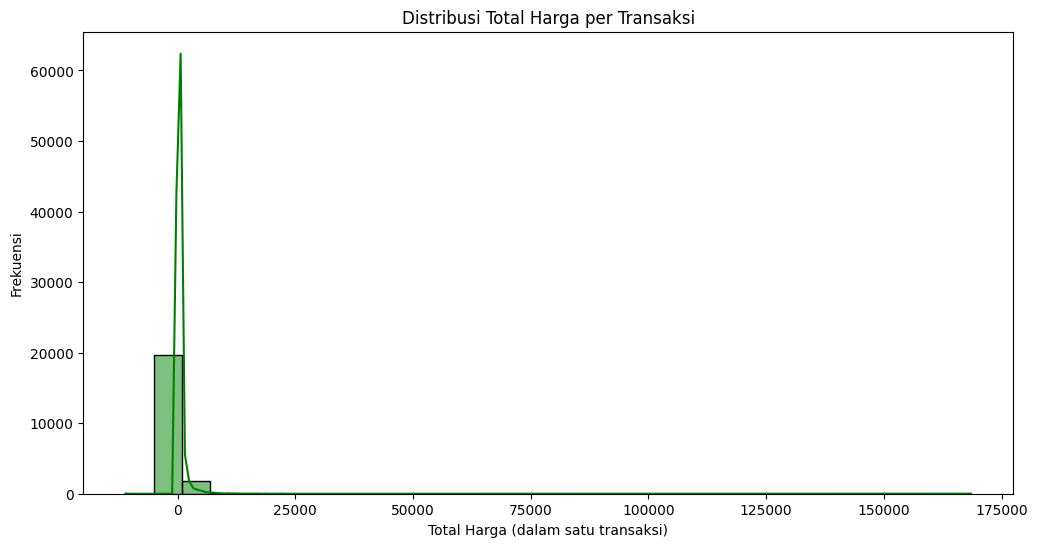

In [13]:
# Total Harga per Transaksi
df['TotalPrice'] = df['Quantity'] * df['Price']
revenue_per_invoice = df.groupby('BillNo')['TotalPrice'].sum()

plt.figure(figsize=(12, 6))
sns.histplot(revenue_per_invoice, bins=30, kde=True, color='green')
plt.title('Distribusi Total Harga per Transaksi')
plt.xlabel('Total Harga (dalam satu transaksi)')
plt.ylabel('Frekuensi')
plt.show()

### Data Preprocessing

In [14]:
# 1. Mengcopy dataframe untuk keamanan
data = df.copy()

In [15]:
# 2. Menghapus kolom
data = data.drop(columns=['CustomerID', 'Price'])

In [16]:
# 3. Menangani Missing value
data.dropna(inplace=True)
print("\nJumlah missing values Akhir")
print(data.isnull().sum())


Jumlah missing values Akhir
BillNo        0
Itemname      0
Quantity      0
Date          0
Country       0
TotalPrice    0
dtype: int64


In [17]:
# 4.Menghapus data duplikat
data.drop_duplicates(inplace=True)
print(data.duplicated().sum())

0



Jumlah outlier pada Quantity: 54539


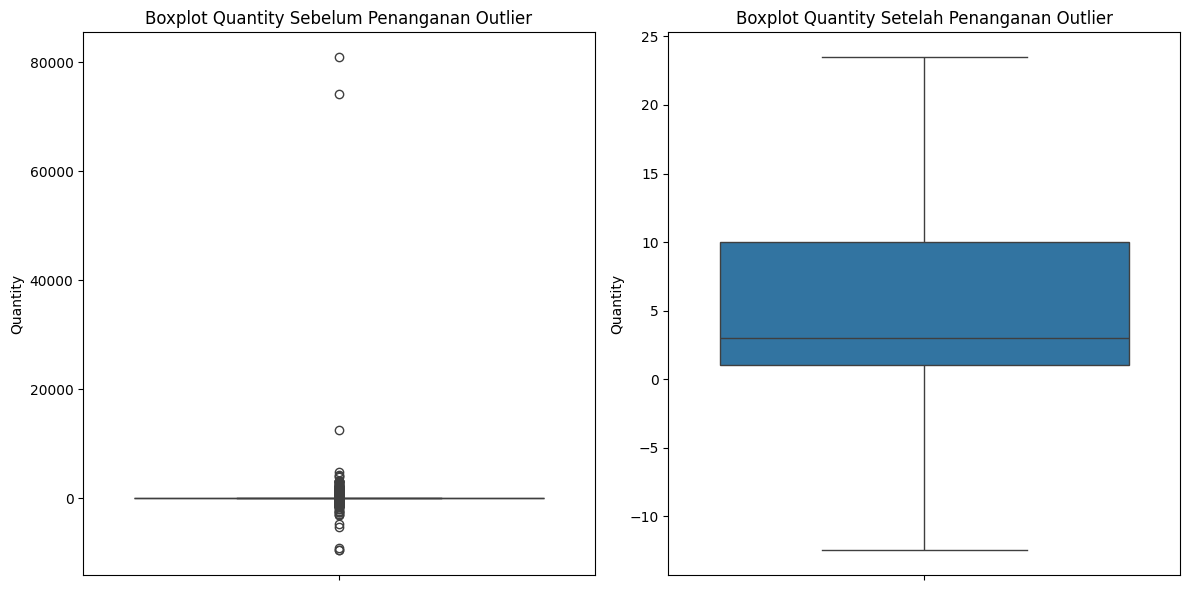

In [18]:
# 5.Fungsi untuk menangani outlier menggunakan metode IQR
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Plot distribusi sebelum penanganan outlier
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot {column} Sebelum Penanganan Outlier')
    
    # Identifikasi outlier
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"\nJumlah outlier pada {column}: {len(outliers)}")
    
    # Capping outlier dengan batas atas dan bawah
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    
    # Plot distribusi setelah penanganan outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot {column} Setelah Penanganan Outlier')
    plt.tight_layout()
    plt.show()
    
    return data

# Tangani outlier hanya pada kolom yang terdeteksi memiliki outlier
for col in ['Quantity']:
    data = handle_outliers(data, col)

In [19]:
# 6. Filter quantity positif (hapus return/refund)
print(f"Data sebelum filter quantity positif: {len(data)}")
data = data[data['Quantity'] > 0]
print(f"Data setelah filter quantity positif: {len(data)}")

Data sebelum filter quantity positif: 515323
Data setelah filter quantity positif: 514850


In [20]:
# 7. Standardisasi nama produk  
data['Itemname'] = data['Itemname'].str.strip().str.upper()
print("Jumlah produk unik: {data['Itemname'].nunique()}")

Jumlah produk unik: {data['Itemname'].nunique()}


In [21]:
# 8. Filter produk dengan frekuensi minimum
min_frequency = 50
product_counts = data['Itemname'].value_counts()
valid_products = product_counts[product_counts >= min_frequency].index
data = data[data['Itemname'].isin(valid_products)]

print(f"Data setelah filter produk (min {min_frequency} kemunculan): {len(data)}")
print(f"Produk unik tersisa: {data['Itemname'].nunique()}")

Data setelah filter produk (min 50 kemunculan): 484478
Produk unik tersisa: 2178


In [22]:
# 9. Filter transaksi dengan item maksimal 50 (hapus bulk order)
transaction_sizes = data.groupby('BillNo').size()
valid_transactions = transaction_sizes[transaction_sizes <= 50].index
data = data[data['BillNo'].isin(valid_transactions)]

print(f"Data setelah filter transaksi outlier: {len(data)}")
print(f"Jumlah transaksi: {data['BillNo'].nunique()}")

Data setelah filter transaksi outlier: 267599
Jumlah transaksi: 17416


In [23]:
# 10. Buat basket untuk market basket analysis
basket_data = data.groupby('BillNo')['Itemname'].apply(list).values
print(f"Total basket/transaksi: {len(basket_data)}")

Total basket/transaksi: 17416


In [24]:
# 11. Transform ke format binary matrix
te = TransactionEncoder()
te_binary = te.fit(basket_data).transform(basket_data)
df_binary = pd.DataFrame(te_binary, columns=te.columns_)

print(f"Shape binary matrix: {df_binary.shape}")

Shape binary matrix: (17416, 2177)


## Modelling

In [25]:
# ========================================
# APRIORI MODELING
# ========================================

print("=== MULAI MODELING APRIORI ===")
print(f"Dataset shape: {df_binary.shape}")
print(f"Total transaksi: {len(df_binary)}")
print(f"Total produk unik: {len(df_binary.columns)}")

# 1. FREQUENT ITEMSETS GENERATION
print("\n1. GENERATING FREQUENT ITEMSETS...")

# Parameter untuk minimum support
min_support = 0.01  # 1% dari total transaksi
print(f"Minimum support: {min_support} ({min_support * len(df_binary):.0f} transaksi)")

# Generate frequent itemsets menggunakan Apriori
frequent_itemsets = apriori(df_binary, 
                           min_support=min_support, 
                           use_colnames=True,
                           max_len=None,  # Tidak ada batasan panjang itemset
                           verbose=1)

# Sorting berdasarkan support
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"\nJumlah frequent itemsets: {len(frequent_itemsets)}")

# Tampilkan statistik frequent itemsets berdasarkan panjang
itemset_lengths = frequent_itemsets['itemsets'].apply(len)
print("\nDistribusi frequent itemsets berdasarkan panjang:")
print(itemset_lengths.value_counts().sort_index())

# Top 10 frequent itemsets
print("\nTop 10 Frequent Itemsets:")
for idx, row in frequent_itemsets.head(10).iterrows():
    items = list(row['itemsets'])
    if len(items) == 1:
        print(f"{idx+1}. {items[0]} (Support: {row['support']:.4f})")
    else:
        print(f"{idx+1}. {items} (Support: {row['support']:.4f})")

# 2. ASSOCIATION RULES GENERATION
print("\n2. GENERATING ASSOCIATION RULES...")

# Parameter untuk association rules
min_threshold = 0.01  # Minimum threshold untuk confidence/lift
print(f"Minimum threshold: {min_threshold}")

# Generate association rules dengan berbagai metrik
metrics = ["confidence", "lift", "support", "conviction"]
rules = association_rules(frequent_itemsets, 
                         metric="confidence", 
                         min_threshold=min_threshold,
                         num_itemsets=len(frequent_itemsets))

# Sorting berdasarkan lift (descending)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"\nJumlah association rules: {len(rules)}")

# Filter rules dengan confidence dan lift yang tinggi
high_quality_rules = rules[(rules['confidence'] >= 0.5) & (rules['lift'] >= 1.5)]
print(f"Jumlah high-quality rules (confidence ≥ 0.5 & lift ≥ 1.5): {len(high_quality_rules)}")

# 3. HASIL MODELING
print("\n3. HASIL MODELING APRIORI")
print("="*50)

# Statistik frequent itemsets
print("FREQUENT ITEMSETS SUMMARY:")
print(f"- Total frequent itemsets: {len(frequent_itemsets)}")
print(f"- Maximum support: {frequent_itemsets['support'].max():.4f}")
print(f"- Minimum support: {frequent_itemsets['support'].min():.4f}")
print(f"- Average support: {frequent_itemsets['support'].mean():.4f}")

# Statistik association rules
if len(rules) > 0:
    print(f"\nASSOCIATION RULES SUMMARY:")
    print(f"- Total rules: {len(rules)}")
    print(f"- High-quality rules: {len(high_quality_rules)}")
    print(f"- Maximum confidence: {rules['confidence'].max():.4f}")
    print(f"- Maximum lift: {rules['lift'].max():.4f}")
    print(f"- Average confidence: {rules['confidence'].mean():.4f}")
    print(f"- Average lift: {rules['lift'].mean():.4f}")

# Top 10 Association Rules
if len(rules) > 0:
    print(f"\nTOP 10 ASSOCIATION RULES (berdasarkan lift):")
    print("-" * 80)
    for idx, row in rules.head(10).iterrows():
        antecedents = list(row['antecedents'])
        consequents = list(row['consequents'])
        
        print(f"{idx+1}. {antecedents} → {consequents}")
        print(f"   Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}")
        print(f"   Conviction: {row['conviction']:.4f} | Leverage: {row['leverage']:.4f}")
        print()

# 4. MENYIMPAN HASIL
print("4. MENYIMPAN HASIL MODELING...")

# Tambahkan kolom untuk interpretasi yang lebih mudah
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets['itemset_string'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

if len(rules) > 0:
    rules['antecedents_string'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents_string'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
    rules['rule_string'] = rules['antecedents_string'] + ' → ' + rules['consequents_string']

print("Modeling Apriori selesai!")
print(f"Variabel yang tersedia:")
print(f"- frequent_itemsets: DataFrame dengan {len(frequent_itemsets)} frequent itemsets")
print(f"- rules: DataFrame dengan {len(rules) if len(rules) > 0 else 0} association rules")
print(f"- high_quality_rules: DataFrame dengan {len(high_quality_rules) if len(rules) > 0 else 0} high-quality rules")

# PARAMETER YANG DAPAT DISESUAIKAN:
print(f"\n=== PARAMETER MODELING ===")
print(f"min_support = {min_support}")
print(f"min_threshold = {min_threshold}")
print(f"Total transaksi = {len(df_binary)}")
print(f"Total produk = {len(df_binary.columns)}")

print("\n=== MODELING SELESAI ===")

=== MULAI MODELING APRIORI ===
Dataset shape: (17416, 2177)
Total transaksi: 17416
Total produk unik: 2177

1. GENERATING FREQUENT ITEMSETS...
Minimum support: 0.01 (174 transaksi)
Processing 164 combinations | Sampling itemset size 4 32

Jumlah frequent itemsets: 576

Distribusi frequent itemsets berdasarkan panjang:
itemsets
1    434
2    131
3     10
4      1
Name: count, dtype: int64

Top 10 Frequent Itemsets:
1. WHITE HANGING HEART T-LIGHT HOLDER (Support: 0.0903)
2. JUMBO BAG RED RETROSPOT (Support: 0.0815)
3. REGENCY CAKESTAND 3 TIER (Support: 0.0798)
4. ASSORTED COLOUR BIRD ORNAMENT (Support: 0.0672)
5. PARTY BUNTING (Support: 0.0671)
6. POSTAGE (Support: 0.0587)
7. LUNCH BAG RED RETROSPOT (Support: 0.0560)
8. SET OF 3 CAKE TINS PANTRY DESIGN (Support: 0.0509)
9. JUMBO BAG PINK POLKADOT (Support: 0.0469)
10. NATURAL SLATE HEART CHALKBOARD (Support: 0.0459)

2. GENERATING ASSOCIATION RULES...
Minimum threshold: 0.01

Jumlah association rules: 336
Jumlah high-quality rules (confi

## Evaluasi dan Visualisasi

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

# ========================================
# EVALUASI AKURASI MODEL APRIORI
# ========================================

print("=== EVALUASI AKURASI MODEL APRIORI ===")

# 1. SPLIT DATA UNTUK VALIDASI
print("\n1. SPLITTING DATA UNTUK VALIDASI...")

# Split data menjadi training dan testing (80:20)
X_train, X_test = train_test_split(df_binary, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} transaksi")
print(f"Test set: {X_test.shape[0]} transaksi")

# Train model pada training set
print("\n2. TRAINING MODEL PADA TRAINING SET...")
min_support_eval = 0.01
frequent_itemsets_train = apriori(X_train, min_support=min_support_eval, use_colnames=True)
rules_train = association_rules(frequent_itemsets_train, metric="confidence", min_threshold=0.01)

print(f"Frequent itemsets dari training: {len(frequent_itemsets_train)}")
print(f"Association rules dari training: {len(rules_train)}")

# 2. EVALUASI BERBASIS PREDIKSI ITEM
print("\n3. EVALUASI BERBASIS PREDIKSI ITEM...")

def predict_items(transaction, rules_df, top_k=5):
    """
    Prediksi item berdasarkan association rules
    """
    predictions = []
    transaction_items = set([col for col in transaction.index if transaction[col] == 1])
    
    for _, rule in rules_df.iterrows():
        antecedents = set(rule['antecedents'])
        consequents = set(rule['consequents'])
        
        # Jika antecedents ada dalam transaksi, prediksi consequents
        if antecedents.issubset(transaction_items):
            for item in consequents:
                if item not in transaction_items:  # Hanya prediksi item yang belum ada
                    predictions.append({
                        'item': item,
                        'confidence': rule['confidence'],
                        'lift': rule['lift']
                    })
    
    # Sort berdasarkan confidence dan ambil top-k
    predictions_df = pd.DataFrame(predictions)
    if len(predictions_df) > 0:
        predictions_df = predictions_df.sort_values('confidence', ascending=False)
        return predictions_df.head(top_k)['item'].tolist()
    else:
        return []

# Evaluasi pada test set
print("Mengevaluasi prediksi pada test set...")
all_predictions = []
all_actuals = []
hit_rates = []

for idx, (_, transaction) in enumerate(X_test.iterrows()):
    if idx % 500 == 0:
        print(f"Progress: {idx}/{len(X_test)}")
    
    # Split transaksi menjadi known items (80%) dan target items (20%)
    transaction_items = [col for col in transaction.index if transaction[col] == 1]
    
    if len(transaction_items) >= 2:  # Minimal 2 item dalam transaksi
        split_point = max(1, int(len(transaction_items) * 0.8))
        known_items = transaction_items[:split_point]
        target_items = transaction_items[split_point:]
        
        # Buat partial transaction dengan known items saja
        partial_transaction = pd.Series(0, index=transaction.index)
        partial_transaction[known_items] = 1
        
        # Prediksi
        predicted_items = predict_items(partial_transaction, rules_train, top_k=5)
        
        # Hitung hit rate
        if len(predicted_items) > 0 and len(target_items) > 0:
            hits = len(set(predicted_items) & set(target_items))
            hit_rate = hits / len(target_items)
            hit_rates.append(hit_rate)
            
            # Untuk precision/recall calculation
            for target_item in target_items:
                all_actuals.append(1 if target_item in predicted_items else 0)
                all_predictions.append(1 if target_item in predicted_items else 0)

# 3. METRIK EVALUASI
print(f"\n4. HASIL EVALUASI...")

if len(hit_rates) > 0:
    avg_hit_rate = np.mean(hit_rates)
    print(f"Average Hit Rate: {avg_hit_rate:.4f}")
    print(f"Hit Rate Std Dev: {np.std(hit_rates):.4f}")
    
    # Precision, Recall, F1-Score
    if len(all_predictions) > 0:
        precision = precision_score(all_actuals, all_predictions, zero_division=0)
        recall = recall_score(all_actuals, all_predictions, zero_division=0)
        f1 = f1_score(all_actuals, all_predictions, zero_division=0)
        
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")

# 4. EVALUASI BERBASIS SUPPORT & CONFIDENCE
print(f"\n5. EVALUASI KUALITAS RULES...")

if len(rules_train) > 0:
    # Analisis distribusi confidence
    confidence_stats = {
        'Mean Confidence': rules_train['confidence'].mean(),
        'Median Confidence': rules_train['confidence'].median(),
        'Std Confidence': rules_train['confidence'].std(),
        'Max Confidence': rules_train['confidence'].max(),
        'Min Confidence': rules_train['confidence'].min()
    }
    
    # Analisis distribusi lift
    lift_stats = {
        'Mean Lift': rules_train['lift'].mean(),
        'Median Lift': rules_train['lift'].median(),
        'Std Lift': rules_train['lift'].std(),
        'Max Lift': rules_train['lift'].max(),
        'Min Lift': rules_train['lift'].min()
    }
    
    print("CONFIDENCE STATISTICS:")
    for key, value in confidence_stats.items():
        print(f"  {key}: {value:.4f}")
    
    print("\nLIFT STATISTICS:")
    for key, value in lift_stats.items():
        print(f"  {key}: {value:.4f}")
    
    # Rules quality assessment
    high_confidence_rules = len(rules_train[rules_train['confidence'] >= 0.7])
    strong_lift_rules = len(rules_train[rules_train['lift'] >= 2.0])
    excellent_rules = len(rules_train[(rules_train['confidence'] >= 0.7) & (rules_train['lift'] >= 2.0)])
    
    print(f"\nRULES QUALITY ASSESSMENT:")
    print(f"  Total Rules: {len(rules_train)}")
    print(f"  High Confidence Rules (≥0.7): {high_confidence_rules} ({high_confidence_rules/len(rules_train)*100:.1f}%)")
    print(f"  Strong Lift Rules (≥2.0): {strong_lift_rules} ({strong_lift_rules/len(rules_train)*100:.1f}%)")
    print(f"  Excellent Rules (Conf≥0.7 & Lift≥2.0): {excellent_rules} ({excellent_rules/len(rules_train)*100:.1f}%)")

# 5. CROSS-VALIDATION DENGAN DIFFERENT SUPPORT THRESHOLDS
print(f"\n6. CROSS-VALIDATION DENGAN BERBAGAI THRESHOLD...")

support_thresholds = [0.005, 0.01, 0.02, 0.03, 0.05]
cv_results = []

for support_thresh in support_thresholds:
    print(f"Testing support threshold: {support_thresh}")
    
    try:
        # Train dengan threshold berbeda
        freq_items = apriori(X_train, min_support=support_thresh, use_colnames=True)
        rules_temp = association_rules(freq_items, metric="confidence", min_threshold=0.01)
        
        # Evaluasi sederhana
        result = {
            'support_threshold': support_thresh,
            'num_frequent_itemsets': len(freq_items),
            'num_rules': len(rules_temp),
            'avg_confidence': rules_temp['confidence'].mean() if len(rules_temp) > 0 else 0,
            'avg_lift': rules_temp['lift'].mean() if len(rules_temp) > 0 else 0,
            'high_quality_rules': len(rules_temp[(rules_temp['confidence'] >= 0.7) & (rules_temp['lift'] >= 2.0)]) if len(rules_temp) > 0 else 0
        }
        cv_results.append(result)
        
    except Exception as e:
        print(f"Error dengan support {support_thresh}: {e}")

# Display cross-validation results
if cv_results:
    cv_df = pd.DataFrame(cv_results)
    print("\nCROSS-VALIDATION RESULTS:")
    print(cv_df.to_string(index=False))
    
    # Find optimal threshold
    if len(cv_df) > 0:
        # Optimal berdasarkan balance antara jumlah rules dan kualitas
        cv_df['quality_score'] = cv_df['high_quality_rules'] / (cv_df['num_rules'] + 1) * cv_df['avg_confidence']
        optimal_idx = cv_df['quality_score'].idxmax()
        optimal_support = cv_df.loc[optimal_idx, 'support_threshold']
        
        print(f"\nOPTIMAL SUPPORT THRESHOLD: {optimal_support}")
        print(f"Quality Score: {cv_df.loc[optimal_idx, 'quality_score']:.4f}")

# 6. BASELINE COMPARISON
print(f"\n7. BASELINE COMPARISON...")

# Random baseline - prediksi item paling populer
popular_items = X_train.sum().sort_values(ascending=False).head(10).index.tolist()
random_hit_rates = []

for idx, (_, transaction) in enumerate(X_test.head(100).iterrows()):  # Sample untuk efisiensi
    transaction_items = [col for col in transaction.index if transaction[col] == 1]
    
    if len(transaction_items) >= 2:
        split_point = max(1, int(len(transaction_items) * 0.8))
        target_items = transaction_items[split_point:]
        
        # Random prediction dari popular items
        random_predictions = popular_items[:5]
        
        if len(target_items) > 0:
            hits = len(set(random_predictions) & set(target_items))
            hit_rate = hits / len(target_items)
            random_hit_rates.append(hit_rate)

if len(random_hit_rates) > 0:
    random_hit_rate = np.mean(random_hit_rates)
    apriori_hit_rate = np.mean(hit_rates) if len(hit_rates) > 0 else 0
    
    print(f"Random Baseline Hit Rate: {random_hit_rate:.4f}")
    print(f"Apriori Model Hit Rate: {apriori_hit_rate:.4f}")
    
    if apriori_hit_rate > 0:
        improvement = ((apriori_hit_rate - random_hit_rate) / random_hit_rate) * 100
        print(f"Improvement over Baseline: {improvement:.1f}%")

# 7. SUMMARY AKURASI
print(f"\n" + "="*50)
print("SUMMARY AKURASI MODEL APRIORI")
print("="*50)

if len(hit_rates) > 0:
    print(f"✓ Average Hit Rate: {np.mean(hit_rates):.4f}")
    print(f"✓ Model Precision: {precision:.4f}")
    print(f"✓ Model Recall: {recall:.4f}")
    print(f"✓ Model F1-Score: {f1:.4f}")

if len(rules_train) > 0:
    print(f"✓ Average Rule Confidence: {rules_train['confidence'].mean():.4f}")
    print(f"✓ Average Rule Lift: {rules_train['lift'].mean():.4f}")
    print(f"✓ High Quality Rules: {excellent_rules}/{len(rules_train)} ({excellent_rules/len(rules_train)*100:.1f}%)")

print(f"✓ Total Frequent Itemsets: {len(frequent_itemsets_train)}")
print(f"✓ Total Association Rules: {len(rules_train)}")

print("\n=== EVALUASI SELESAI ===")

=== EVALUASI AKURASI MODEL APRIORI ===

1. SPLITTING DATA UNTUK VALIDASI...
Training set: 13932 transaksi
Test set: 3484 transaksi

2. TRAINING MODEL PADA TRAINING SET...
Frequent itemsets dari training: 570
Association rules dari training: 334

3. EVALUASI BERBASIS PREDIKSI ITEM...
Mengevaluasi prediksi pada test set...
Progress: 0/3484
Progress: 500/3484
Progress: 1000/3484
Progress: 1500/3484
Progress: 2000/3484
Progress: 2500/3484
Progress: 3000/3484

4. HASIL EVALUASI...
Average Hit Rate: 0.0671
Hit Rate Std Dev: 0.1819
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

5. EVALUASI KUALITAS RULES...
CONFIDENCE STATISTICS:
  Mean Confidence: 0.4161
  Median Confidence: 0.3860
  Std Confidence: 0.1745
  Max Confidence: 0.9114
  Min Confidence: 0.1168

LIFT STATISTICS:
  Mean Lift: 12.9679
  Median Lift: 10.2745
  Std Lift: 7.6931
  Max Lift: 50.9975
  Min Lift: 1.8293

RULES QUALITY ASSESSMENT:
  Total Rules: 334
  High Confidence Rules (≥0.7): 26 (7.8%)
  Strong Lift Rules (≥2.0): 

## Uji Coba